!git clone https://github.com/No-Country-simulation/g9-br-team-34-techmind.git

%cd g9-br-team-34-techmind/

!git config --global user.name "Vanzhel01"
!git config --global user.email "huanucoluigui@gmail.com"

!git checkout Luigui_branch
#Si quieres usar otra branch cambia el nombre en caso de que quieras crear una nueva y usar esa usa:
#!git checkout -b su_propia_branch

!git branch

!pip install spacy joblib
!python -m spacy download es_core_news_sm

In [1]:
"""
Entrenamiento del modelo de clasificación de contenido técnico
Pipeline: EDA -> Limpieza -> TF-IDF -> Regresión Logística -> Métricas -> Serialización

Requisitos:
    pip install scikit-learn pandas spacy joblib matplotlib
    python -m spacy download es_core_news_sm

"""

import re
import string
import joblib
import spacy
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [2]:
#dataset = pd.read_json("/content/g9-br-team-34-techmind/data-science/data/dataset.json")
dataset = pd.read_json("../data/v3.1.json")
dataset

,titulo,descripcion,tags,categoria
0,¿Puedo utilizar JPasswordField con un JOptionP...,Me estoy iniciando en Java y estoy trabajando ...,"[java, joptionpane]",backend
1,Como imprimir correctamente el salto de linea ...,estoy tratando de crear un mensaje que se auto...,"[php, web, whatsapp, mensajes]",backend
2,Validación formularios Spring,Intento hacer una serie de validaciones sobre ...,[spring],backend
3,Cambiar status automáticamente a 1 o 0 con php...,No puedo cambiar el status a 1 o 0 si el inven...,"[php, mysql]",backend
4,"¿Por qué no me carga el formulario tipo ""POST""?",Explico un poco lo que quiero hacer: es para u...,"[python, django]",backend
...,...,...,...,...
3595,"Mitos comunes sobre Node.js, JavaScript y Bash","Existe el mito de que Node.js, JavaScript y Ba...","[node.js, javascript, bash]",seguridad
3596,Lo que todos creen (mal) sobre trabajar en mod...,Existe el mito de que scikit-learn y MATLAB so...,"[scikit-learn, matlab]",machine learning
3597,"El eterno debate sobre Pandas, SQL, Julia y R",Siempre surge el mismo debate en foros de desa...,"[pandas, sql, julia, r]",machine learning
3598,Lo que nadie te dice sobre Jetpack Compose y S...,Si estás empezando con Jetpack Compose y Swift...,"[jetpack compose, swiftui]",mobile


In [3]:
# -----------------------------------------------------------------------
# EDA
# -----------------------------------------------------------------------

def eda(df: pd.DataFrame) -> None:
    print("Filas totales:", len(df))

    print(df["categoria"].value_counts())

    df["longitud"] = df["descripcion"].str.split().apply(len)
    print("\nLongitud de descripcion (en palabras) por categoría:")
    print(df.groupby("categoria")["longitud"].describe()[["mean", "min", "max"]])

    # Gráfico simple de distribución de clases
    df["categoria"].value_counts().plot(kind="bar", figsize=(8, 4), title="Distribución de clases")
    plt.tight_layout()
    #plt.savefig("eda_distribucion_clases.png")
    plt.show()
    #print("\nGráfico guardado en eda_distribucion_clases.png")

In [4]:
import matplotlib.pyplot as plt
import pandas as pd


def eda(df: pd.DataFrame) -> None:
    print("Filas totales:", len(df))
    print(df["categoria"].value_counts())

    df["longitud"] = df["descripcion"].str.split().apply(len)
    print("\nLongitud de descripcion (en palabras) por categoría:")
    print(df.groupby("categoria")["longitud"].describe()[["mean", "min", "max"]])

    # Gráfico de distribución de clases
    fig, ax = plt.subplots(figsize=(8, 4))

    # 1. rot=0 hace que el texto del eje X sea horizontal
    counts = df["categoria"].value_counts()
    bars = counts.plot(
        kind="bar",
        ax=ax,
        rot=0,
        title="Distribución de clases",
        color="#1f77b4",
    )

    # 2. Agrega los números DENTRO de las barras (center) y en blanco para que resalten
    ax.bar_label(ax.containers[0], label_type="center", color="white", fontweight="bold")

    # Opcional: Ajustar el rango del eje Y para que no se corte el título
    ax.set_ylim(0, counts.max() * 1.15)

    plt.tight_layout()
    # plt.savefig("eda_distribucion_clases.png")
    plt.show()

Filas totales: 3600
categoria
machine learning    576
mobile              575
seguridad           575
devops              469
base de datos       469
backend             469
frontend            467
Name: count, dtype: int64

Longitud de descripcion (en palabras) por categoría:
                       mean   min    max
categoria                               
backend           90.547974  10.0  999.0
base de datos     81.332623   9.0  536.0
devops            83.562900  12.0  670.0
frontend          80.408994   8.0  545.0
machine learning  78.512153   9.0  819.0
mobile            72.890435  12.0  858.0
seguridad         78.913043  14.0  619.0


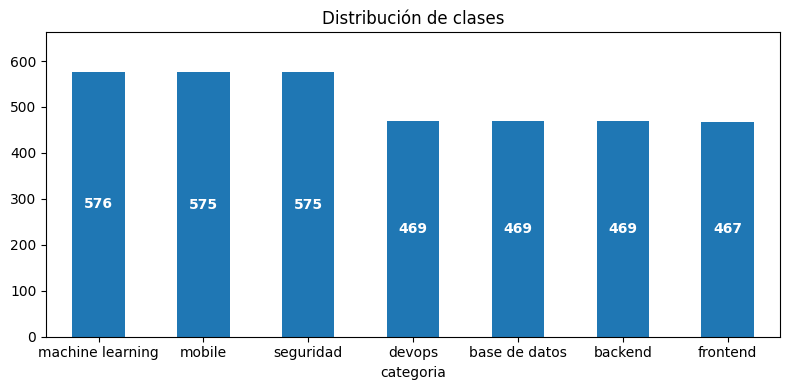

In [5]:
eda(dataset)

## Preprocesamiento y limpieza del dataset

In [6]:
# -----------------------------------------------------------------------
# LIMPIEZA / PREPROCESAMIENTO EN ESPAÑOL
# -----------------------------------------------------------------------

# Carga el modelo de spaCy en español (solo tokenizer + lematizador, sin NER/parser para que sea rápido)
_nlp = spacy.load("es_core_news_sm", disable=["ner", "parser"])

# Palabras propias del dominio técnico que NO deben tratarse como stopwords
EXCEPCIONES = {
    #Backend / lenguajes
    "api", "rest", "soap", "orm", "jwt", "sdk", "cli", "php", "java",
    "cplusplus", "csharp", "fsharp", "dotnet", "nodejs", "go", "rust",
    # Frontend
    "css", "html", "js", "ts", "ux", "ui", "reactjs", "vuejs", "angularjs",
    "seo",
    # Base de datos
    "sql", "nosql",
    # DevOps
    "git", "ci", "cd", "cicd", "aws", "gcp", "k8s", "ssh", "vpn", "dns",
    "ftp", "tcp", "ip", "http", "https", "json", "xml", "yaml", "npm",
    "pip", "venv", "docker",
    # Machine Learning
    "ai", "ml", "nlp", "gpu", "cpu", "ram",
    # Seguridad
    "oauth", "sso",
    # Mobile
    "ios", "apk",
}

# Términos técnicos compuestos que el regex de limpieza destruiría
# (ej. "c++" -> "c", "c#" -> "c", ".net" -> "net") si no se protegen
NORMALIZACIONES = {
    r"\bc\+\+": "cplusplus",
    r"\bc#": "csharp",
    r"\bf#": "fsharp",
    r"\.net\b": "dotnet",
    r"\bnode\.js\b": "nodejs",
    r"\bvue\.js\b": "vuejs",
    r"\breact\.js\b": "reactjs",
    r"\bangular\.js\b": "angularjs",
    r"\bci\s*/\s*cd\b": "cicd",
}

def limpiar_texto(texto: str) -> str:
    """Normaliza, quita stopwords, lematiza. Pensado para alimentar TF-IDF."""
    texto = texto.lower()

    # Protege términos compuestos ANTES de quitar símbolos como + # .
    for patron, reemplazo in NORMALIZACIONES.items():
        texto = re.sub(patron, reemplazo, texto)

    texto = re.sub(r"http\S+|www\.\S+", " ", texto)          # URLs
    texto = re.sub(r"[^\w\sáéíóúñü]", " ", texto)              # puntuación, conserva tildes/ñ
    texto = re.sub(r"\d+", " ", texto)                         # números
    texto = re.sub(r"\s+", " ", texto).strip()

    doc = _nlp(texto)
    tokens = [
        tok.lemma_ for tok in doc
        if (not tok.is_stop or tok.text in EXCEPCIONES)
        and not tok.is_punct
        and len(tok.text) > 1
    ]
    return " ".join(tokens)

def preprocesar_dataset(df: pd.DataFrame) -> pd.DataFrame:
    df["descripcion_limpia"] = df["descripcion"].apply(limpiar_texto)
    df["titulo_limpio"] = df["titulo"].apply(limpiar_texto)
    return df

In [7]:
dataset = preprocesar_dataset(dataset)
dataset

,titulo,descripcion,tags,categoria,longitud,descripcion_limpia,titulo_limpio
0,¿Puedo utilizar JPasswordField con un JOptionP...,Me estoy iniciando en Java y estoy trabajando ...,"[java, joptionpane]",backend,96,iniciar java trabajar ahorcado proyecto duda c...,utilizar jpasswordfield joptionpane necesidad ...
1,Como imprimir correctamente el salto de linea ...,estoy tratando de crear un mensaje que se auto...,"[php, web, whatsapp, mensajes]",backend,74,tratar crear mensaje autorellenar dato cliente...,imprimir correctamente salto linea enlace exte...
2,Validación formularios Spring,Intento hacer una serie de validaciones sobre ...,[spring],backend,74,intento serie validación formulario hibernate ...,validación formulario spring
3,Cambiar status automáticamente a 1 o 0 con php...,No puedo cambiar el status a 1 o 0 si el inven...,"[php, mysql]",backend,82,cambiar status inventario ocupado libre dar él...,cambiar status automáticamente php mysql
4,"¿Por qué no me carga el formulario tipo ""POST""?",Explico un poco lo que quiero hacer: es para u...,"[python, django]",backend,202,explico querer sitio tipo blog idea usuario lo...,cargar formulario tipo post
...,...,...,...,...,...,...,...
3595,"Mitos comunes sobre Node.js, JavaScript y Bash","Existe el mito de que Node.js, JavaScript y Ba...","[node.js, javascript, bash]",seguridad,50,mito nodejs javascript bash principiante prueb...,mito común nodejs javascript bash
3596,Lo que todos creen (mal) sobre trabajar en mod...,Existe el mito de que scikit-learn y MATLAB so...,"[scikit-learn, matlab]",machine learning,46,mito scikit learn matlab principiant modelo ap...,creer trabajar modelo aprendizaje automático
3597,"El eterno debate sobre Pandas, SQL, Julia y R",Siempre surge el mismo debate en foros de desa...,"[pandas, sql, julia, r]",machine learning,53,surgir debate foro desarrollador panda sql jul...,eterno debate panda sql julio
3598,Lo que nadie te dice sobre Jetpack Compose y S...,Si estás empezando con Jetpack Compose y Swift...,"[jetpack compose, swiftui]",mobile,50,estar empezar jetpack compo él swiftui apps co...,jetpack compo él swiftui


## Vectorización, Entrenamiento y métricas

In [8]:
# -----------------------------------------------------------------------
# VECTORIZACIÓN
# -----------------------------------------------------------------------
from scipy.sparse import hstack

def construir_features(df, test_size=0.2, random_state=42, peso_titulo=0.5):
    X_train_df, X_test_df, y_train, y_test = train_test_split(
        df[["titulo_limpio", "descripcion_limpia"]], df["categoria"],
        test_size=test_size, random_state=random_state, stratify=df["categoria"]
    )

    vect_titulo = TfidfVectorizer(max_features=1000, ngram_range=(1, 2), min_df=2)
    vect_texto = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=2, sublinear_tf=True)

    Xtr_titulo = vect_titulo.fit_transform(X_train_df["titulo_limpio"]) * peso_titulo
    Xtr_texto = vect_texto.fit_transform(X_train_df["descripcion_limpia"])
    X_train_tfidf = hstack([Xtr_titulo, Xtr_texto])

    Xte_titulo = vect_titulo.transform(X_test_df["titulo_limpio"]) * peso_titulo
    Xte_texto = vect_texto.transform(X_test_df["descripcion_limpia"])
    X_test_tfidf = hstack([Xte_titulo, Xte_texto])

    return vect_titulo, vect_texto, X_train_tfidf, y_train, X_test_tfidf, y_test

In [9]:
# -----------------------------------------------------------------------
# ENTRENAMIENTO
# -----------------------------------------------------------------------

from sklearn.model_selection import GridSearchCV

def afinar_hiperparametros(X_train_tfidf, y_train):
    param_grid = {
        "C": [0.01, 0.05, 0.1, 0.3, 0.5, 1.0],
        "class_weight": ["balanced", None],
    }
    grid = GridSearchCV(
        LogisticRegression(max_iter=1000),
        param_grid, cv=5, scoring="f1_macro", n_jobs=-1
    )
    grid.fit(X_train_tfidf, y_train)

    print("Mejores parámetros:", grid.best_params_)
    print(f"Mejor F1 macro (CV): {grid.best_score_:.4f}")
    return grid.best_estimator_

In [10]:
# -----------------------------------------------------------------------
# MÉTRICAS
# -----------------------------------------------------------------------

from sklearn.model_selection import StratifiedKFold, cross_val_score

def validacion_cruzada(df, peso_titulo: float = 2.0, k: int = 5):
    """Valida que el F1 macro sea estable y no dependa de qué filas cayeron en el split."""
    vect_titulo = TfidfVectorizer(max_features=1000, ngram_range=(1, 2), min_df=2)
    vect_texto = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=2, sublinear_tf=True)

    X_titulo = vect_titulo.fit_transform(df["titulo_limpio"]) * peso_titulo
    X_texto = vect_texto.fit_transform(df["descripcion_limpia"])
    X_tfidf = hstack([X_titulo, X_texto])

    skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)
    modelo_cv = LogisticRegression(max_iter=1000, class_weight="balanced", C=1.0)
    scores = cross_val_score(modelo_cv, X_tfidf, df["categoria"], cv=skf, scoring="f1_macro")

    print(f"F1 macro por fold: {scores.round(4)}")
    print(f"F1 macro promedio: {scores.mean():.4f} (+/- {scores.std():.4f})")
    return scores

In [11]:
from sklearn.metrics import f1_score, balanced_accuracy_score

def evaluar(modelo, X_test_tfidf, y_test) -> None:
    y_pred = modelo.predict(X_test_tfidf)

    print("Reporte de clasificación:\n")
    print(classification_report(y_test, y_pred))

    f1_macro = f1_score(y_test, y_pred, average="macro")
    balanced_acc = balanced_accuracy_score(y_test, y_pred)
    print(f"F1 macro (métrica principal recomendada): {f1_macro:.4f}")
    print(f"Balanced accuracy: {balanced_acc:.4f}")

    cm = confusion_matrix(y_test, y_pred, labels=modelo.classes_)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=modelo.classes_)
    fig, ax = plt.subplots(figsize=(8, 8))
    disp.plot(ax=ax, xticks_rotation=45, cmap="Blues", colorbar=False)
    plt.tight_layout()
    #plt.savefig("matriz_confusion.png")
    plt.show()
    #print("Matriz de confusión guardada en matriz_confusion.png")


In [12]:
print("\n--- Validación cruzada (estabilidad del modelo) ---")
validacion_cruzada(dataset, peso_titulo=0.5)



--- Validación cruzada (estabilidad del modelo) ---
F1 macro por fold: [0.8663 0.8648 0.8602 0.8695 0.8772]
F1 macro promedio: 0.8676 (+/- 0.0057)


array([0.86630305, 0.86482937, 0.86020511, 0.86952996, 0.87720467])

Mejores parámetros: {'C': 1.0, 'class_weight': None}
Mejor F1 macro (CV): 0.8605
Reporte de clasificación:

                  precision    recall  f1-score   support

         backend       0.84      0.81      0.83        94
   base de datos       0.81      0.90      0.85        94
          devops       0.91      0.89      0.90        94
        frontend       0.86      0.91      0.89        93
machine learning       0.95      0.92      0.94       115
          mobile       0.93      0.95      0.94       115
       seguridad       0.95      0.88      0.91       115

        accuracy                           0.90       720
       macro avg       0.90      0.90      0.89       720
    weighted avg       0.90      0.90      0.90       720

F1 macro (métrica principal recomendada): 0.8944
Balanced accuracy: 0.8955


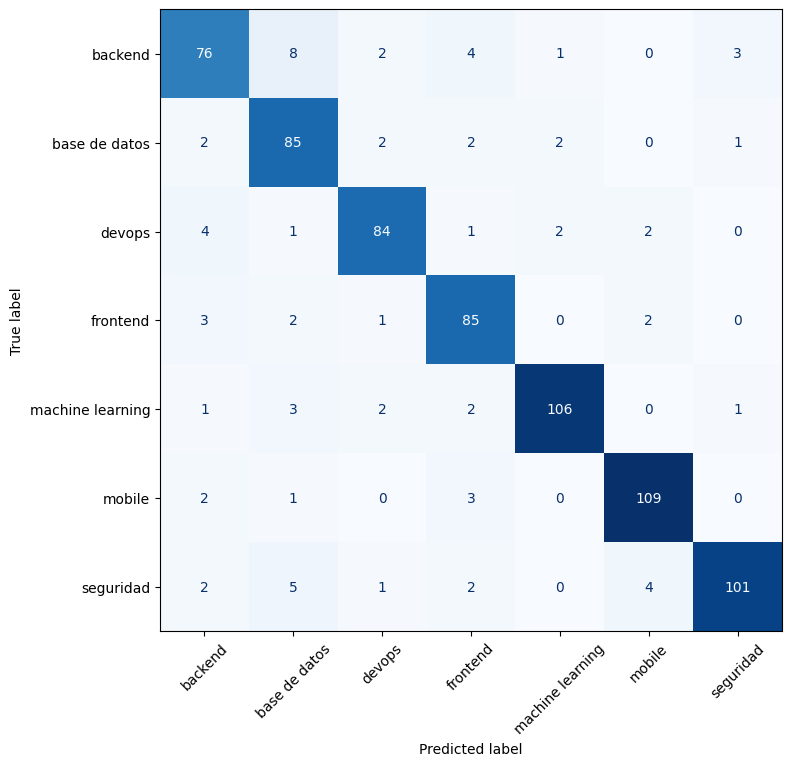

In [13]:
vect_titulo, vect_texto, X_train_tfidf, y_train, X_test_tfidf, y_test = construir_features(dataset, peso_titulo=0.5)
modelo = afinar_hiperparametros(X_train_tfidf, y_train)

evaluar(modelo, X_test_tfidf, y_test)

## Overfitting

In [14]:
def diagnosticar_overfitting(modelo, X_train_tfidf, y_train, X_test_tfidf, y_test) -> None:
    score_train = modelo.score(X_train_tfidf, y_train)
    score_test = modelo.score(X_test_tfidf, y_test)
    brecha = score_train - score_test

    print(f"Accuracy train: {score_train:.4f}")
    print(f"Accuracy test:  {score_test:.4f}")
    print(f"Brecha (train - test): {brecha:.4f}")

    if brecha > 0.15:
        print("Brecha grande: posible overfitting. Considera más datos, "
              "bajar max_features, o subir la regularización (bajar C).")
    else:
        print("Brecha razonable: el modelo generaliza bien al set de test.")

In [15]:
diagnosticar_overfitting(modelo, X_train_tfidf, y_train, X_test_tfidf, y_test)


Accuracy train: 0.9743
Accuracy test:  0.8972
Brecha (train - test): 0.0771
Brecha razonable: el modelo generaliza bien al set de test.


## Guardando modelos

In [40]:
# -----------------------------------------------------------------------
# SERIALIZACIÓN (joblib)
# -----------------------------------------------------------------------
def guardar_modelo(modelo, vect_titulo, vect_texto,
                    ruta_modelo: str = "../models/modelo_clasificador.joblib",
                    ruta_vect_titulo: str = "../models/tfidf_titulo.joblib",
                    ruta_vect_texto: str = "../models/tfidf_texto.joblib") -> None:
    joblib.dump(modelo, ruta_modelo)
    joblib.dump(vect_titulo, ruta_vect_titulo)
    joblib.dump(vect_texto, ruta_vect_texto)
    print(f"Modelo guardado en: {ruta_modelo}")
    print(f"Vectorizador de título guardado en: {ruta_vect_titulo}")
    print(f"Vectorizador de texto guardado en: {ruta_vect_texto}")


In [41]:
guardar_modelo(modelo, vect_titulo, vect_texto)

Modelo guardado en: ../models/modelo_clasificador.joblib
Vectorizador de título guardado en: ../models/tfidf_titulo.joblib
Vectorizador de texto guardado en: ../models/tfidf_texto.joblib


## Funcion de respuesta (JSON)

In [18]:
# -----------------------------------------------------------------------
# FUNCIÓN JSON
# -----------------------------------------------------------------------
def predecir_json_separado(titulo, texto, modelo, vect_titulo, vect_texto,
                            peso_titulo=2.0, top_n_palabras=5):
    v_titulo = vect_titulo.transform([limpiar_texto(titulo)]) * peso_titulo
    v_texto = vect_texto.transform([limpiar_texto(texto)])
    vector = hstack([v_titulo, v_texto])

    categoria = modelo.predict(vector)[0]
    probabilidad = round(float(max(modelo.predict_proba(vector)[0])), 4)

    nombres_features = list(vect_titulo.get_feature_names_out()) + list(vect_texto.get_feature_names_out())

    vector_denso = vector.toarray()[0]
    indices_top = vector_denso.argsort()[::-1][:top_n_palabras]
    palabras_clave = [nombres_features[i] for i in indices_top if vector_denso[i] > 0]

    return {
        "categoria": categoria,
        "probabilidad": probabilidad,
        "informacion_adicional": palabras_clave,
    }

## Prueba con ejemplos sinteticos

In [19]:
ejemplos_prueba = [
    # --- Backend ---
    ("Creando una API REST con Spring Boot",
     "Aprende a construir servicios web con Java y Spring Boot, incluyendo controladores, endpoints y manejo de excepciones."),
    ("Autenticación con JWT en Node.js",
     "Implementa autenticación segura en tu backend usando tokens JWT, middleware de Express y validación de sesiones."),

    # --- Frontend ---
    ("Componentes reutilizables en React",
     "Este tutorial explica cómo crear componentes reutilizables usando props y hooks en aplicaciones React modernas."),
    ("Diseño responsivo con CSS Grid",
     "Aprende a maquetar sitios web adaptables a distintos tamaños de pantalla utilizando CSS Grid y Flexbox."),

    # --- Base de Datos ---
    ("Optimización de consultas SQL",
     "Este artículo cubre el uso de índices, joins eficientes y análisis de planes de ejecución en bases de datos relacionales."),
    ("Modelado de datos en MongoDB",
     "Explora cómo diseñar esquemas flexibles en bases de datos NoSQL usando documentos y colecciones en MongoDB."),

    # --- Mobile ---
    ("Desarrollo multiplataforma con Flutter",
     "Aprende a crear aplicaciones móviles para Android e iOS desde un solo código base usando Flutter y Dart."),
    ("Notificaciones push en Android",
     "Implementa notificaciones push utilizando Firebase Cloud Messaging en aplicaciones Android nativas."),

    # --- DevOps ---
    ("Contenedores con Docker y Docker Compose",
     "Aprende a empaquetar aplicaciones en contenedores Docker y orquestar múltiples servicios con Docker Compose."),
    ("Integración continua con GitHub Actions",
     "Configura pipelines de CI/CD automatizados para ejecutar pruebas y desplegar tu aplicación en cada commit."),

    # --- Machine Learning ---
    ("Introducción a redes neuronales con TensorFlow",
     "Este contenido explica los conceptos básicos de deep learning y cómo entrenar un modelo simple con TensorFlow."),
    ("Procesamiento de lenguaje natural en español",
     "Aprende técnicas de NLP como tokenización, lematización y vectorización TF-IDF aplicadas a textos en español."),

    # --- Seguridad ---
    ("Prevención de inyección SQL",
     "Este artículo explica cómo proteger aplicaciones web contra ataques de inyección SQL mediante consultas parametrizadas."),
    ("Autenticación de dos factores (2FA)",
     "Implementa autenticación de dos factores usando OAuth y aplicaciones autenticadoras para mejorar la seguridad de tus usuarios."),

    # --- Casos ambiguos / a propósito difíciles (mezclan categorías) ---
    ("Desplegando un modelo de Machine Learning con Docker",
     "Aprende a contenerizar un modelo entrenado en scikit-learn y exponerlo como una API REST usando FastAPI y Docker."),
    ("Seguridad en APIs REST",
     "Este contenido cubre buenas prácticas de seguridad para proteger endpoints, incluyendo autenticación JWT y validación de entradas."),
    ("Base de datos para aplicaciones móviles offline-first",
     "Explora cómo sincronizar datos locales en SQLite con una base de datos remota en aplicaciones Android sin conexión constante."),

    # --- Casos cortos / poco contexto (stress test de textos breves) ---
    ("Git para principiantes",
     "Comandos básicos de control de versiones: commit, push, pull y ramas."),
    ("¿Qué es un JOIN en SQL?",
     "Breve explicación sobre cómo combinar tablas en una base de datos relacional."),
]

print(f"Probando {len(ejemplos_prueba)} ejemplos:\n")
for titulo, texto in ejemplos_prueba:
    resultado = predecir_json_separado(titulo, texto, modelo, vect_titulo, vect_texto)
    print(f"[{titulo}]")
    print(f"  -> {resultado}\n")

Probando 19 ejemplos:

[Creando una API REST con Spring Boot]
  -> {'categoria': 'backend', 'probabilidad': 0.9879, 'informacion_adicional': ['rest', 'spring boot', 'boot', 'api', 'crear']}

[Autenticación con JWT en Node.js]
  -> {'categoria': 'backend', 'probabilidad': 0.7061, 'informacion_adicional': ['autenticación', 'nodejs', 'jwt', 'implemento', 'tokens']}

[Componentes reutilizables en React]
  -> {'categoria': 'mobile', 'probabilidad': 0.7155, 'informacion_adicional': ['componente', 'react', 'props', 'crear componente', 'explicar']}

[Diseño responsivo con CSS Grid]
  -> {'categoria': 'frontend', 'probabilidad': 0.8956, 'informacion_adicional': ['diseño', 'css', 'tamaño pantalla', 'sitio web', 'maquetar']}

[Optimización de consultas SQL]
  -> {'categoria': 'base de datos', 'probabilidad': 0.9871, 'informacion_adicional': ['consulta sql', 'optimización', 'consulta', 'sql', 'cubrir']}

[Modelado de datos en MongoDB]
  -> {'categoria': 'base de datos', 'probabilidad': 0.9997, 'in

## Resumen de confianza y Palabras mas influyentes

In [20]:
def resumen_confianza(ejemplos_prueba, modelo, vect_titulo, vect_texto, umbral=0.5):
    inciertos = []
    for titulo, texto in ejemplos_prueba:
        r = predecir_json_separado(titulo, texto, modelo, vect_titulo, vect_texto)
        if r["probabilidad"] < umbral:
            inciertos.append((titulo, r))

    print(f"{len(inciertos)} de {len(ejemplos_prueba)} ejemplos con probabilidad < {umbral}")
    for titulo, r in inciertos:
        print(f"  [{titulo}] -> {r}")

In [21]:
resumen_confianza(ejemplos_prueba, modelo, vect_titulo, vect_texto)

0 de 19 ejemplos con probabilidad < 0.5


In [22]:
def palabras_mas_influyentes_por_categoria(modelo, vect_titulo, vect_texto, top_n=10):
    """
    Para cada categoría, muestra las palabras que más 'empujan' al modelo
    hacia esa clase, según el coeficiente de la Regresión Logística.
    Distingue si la palabra viene del título o del cuerpo del texto.
    """
    nombres_titulo = list(vect_titulo.get_feature_names_out())
    nombres_texto = list(vect_texto.get_feature_names_out())
    nombres = nombres_titulo + nombres_texto
    n_titulo = len(nombres_titulo)

    resultados = {}
    for i, categoria in enumerate(modelo.classes_):
        coeficientes = modelo.coef_[i]
        top_indices = coeficientes.argsort()[::-1][:top_n]

        palabras_info = []
        for idx in top_indices:
            origen = "titulo" if idx < n_titulo else "texto"
            palabras_info.append({
                "palabra": nombres[idx],
                "peso": round(float(coeficientes[idx]), 4),
                "origen": origen,
            })

        resultados[categoria] = palabras_info
        print(f"\n{categoria}:")
        for p in palabras_info:
            print(f"  {p['palabra']:20s} peso={p['peso']:+.4f}  ({p['origen']})")

    return resultados

In [23]:
print("\n--- Explicabilidad: palabras más influyentes por categoría ---")
palabras_mas_influyentes_por_categoria(modelo, vect_titulo, vect_texto)


--- Explicabilidad: palabras más influyentes por categoría ---

backend:
  django               peso=+2.6228  (titulo)
  django               peso=+2.4263  (texto)
  spring               peso=+2.2883  (texto)
  microservicio        peso=+2.1924  (texto)
  arquitectura         peso=+2.1709  (texto)
  spring               peso=+2.1613  (titulo)
  arquitectura microservicio peso=+2.1602  (texto)
  java                 peso=+2.1335  (titulo)
  backend aplicación   peso=+2.0245  (texto)
  aplicación web       peso=+1.8730  (texto)

base de datos:
  consulta             peso=+3.4173  (texto)
  mongodb              peso=+3.1857  (titulo)
  tabla                peso=+3.0008  (texto)
  sql                  peso=+2.8038  (titulo)
  postgresql           peso=+2.2861  (titulo)
  esquema              peso=+2.2659  (texto)
  sql                  peso=+2.1597  (texto)
  orms                 peso=+2.0175  (texto)
  esquema orms         peso=+2.0175  (texto)
  diseño esquema       peso=+2.0175  (texto

{'backend': [{'palabra': 'django', 'peso': 2.6228, 'origen': 'titulo'},
  {'palabra': 'django', 'peso': 2.4263, 'origen': 'texto'},
  {'palabra': 'spring', 'peso': 2.2883, 'origen': 'texto'},
  {'palabra': 'microservicio', 'peso': 2.1924, 'origen': 'texto'},
  {'palabra': 'arquitectura', 'peso': 2.1709, 'origen': 'texto'},
  {'palabra': 'spring', 'peso': 2.1613, 'origen': 'titulo'},
  {'palabra': 'arquitectura microservicio', 'peso': 2.1602, 'origen': 'texto'},
  {'palabra': 'java', 'peso': 2.1335, 'origen': 'titulo'},
  {'palabra': 'backend aplicación', 'peso': 2.0245, 'origen': 'texto'},
  {'palabra': 'aplicación web', 'peso': 1.873, 'origen': 'texto'}],
 'base de datos': [{'palabra': 'consulta', 'peso': 3.4173, 'origen': 'texto'},
  {'palabra': 'mongodb', 'peso': 3.1857, 'origen': 'titulo'},
  {'palabra': 'tabla', 'peso': 3.0008, 'origen': 'texto'},
  {'palabra': 'sql', 'peso': 2.8038, 'origen': 'titulo'},
  {'palabra': 'postgresql', 'peso': 2.2861, 'origen': 'titulo'},
  {'palabra'

In [24]:
import matplotlib.pyplot as plt

def graficar_palabras_influyentes(modelo, vect_titulo, vect_texto, categoria, top_n=10):
    resultados = palabras_mas_influyentes_por_categoria(modelo, vect_titulo, vect_texto, top_n)
    datos = resultados[categoria]

    palabras = [d["palabra"] for d in datos][::-1]
    pesos = [d["peso"] for d in datos][::-1]

    plt.figure(figsize=(7, 5))
    plt.barh(palabras, pesos, color="steelblue")
    plt.title(f"Palabras más influyentes: {categoria}")
    plt.xlabel("Peso (coeficiente)")
    plt.tight_layout()
    plt.show()
    #plt.savefig(f"explicabilidad_{categoria}.png")

    #print(f"Gráfico guardado: explicabilidad_{categoria}.png")


backend:
  django               peso=+2.6228  (titulo)
  django               peso=+2.4263  (texto)
  spring               peso=+2.2883  (texto)
  microservicio        peso=+2.1924  (texto)
  arquitectura         peso=+2.1709  (texto)
  spring               peso=+2.1613  (titulo)
  arquitectura microservicio peso=+2.1602  (texto)
  java                 peso=+2.1335  (titulo)
  backend aplicación   peso=+2.0245  (texto)
  aplicación web       peso=+1.8730  (texto)

base de datos:
  consulta             peso=+3.4173  (texto)
  mongodb              peso=+3.1857  (titulo)
  tabla                peso=+3.0008  (texto)
  sql                  peso=+2.8038  (titulo)
  postgresql           peso=+2.2861  (titulo)
  esquema              peso=+2.2659  (texto)
  sql                  peso=+2.1597  (texto)
  orms                 peso=+2.0175  (texto)
  esquema orms         peso=+2.0175  (texto)
  diseño esquema       peso=+2.0175  (texto)

devops:
  docker               peso=+3.4743  (texto)
  git   

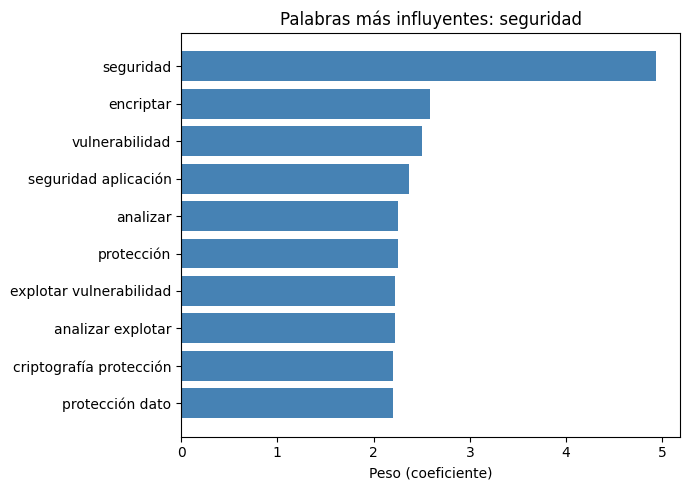

In [25]:
graficar_palabras_influyentes(modelo, vect_titulo, vect_texto, categoria="seguridad")

## Subiendo modelos al repositorio

In [26]:
#from google.colab import userdata
#token = userdata.get('GITHUB_TOKEN')

In [27]:
#%cd g9-br-team-34-techmind/

In [28]:
#!git add data-science/
#!git commit -m "model update"
#!git push https://{token}@github.com/No-Country-simulation/g9-br-team-34-techmind.git Luigui_branch